[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/22_0_preprocessing.ipynb)



# Le prétraitement des données

Un modèle ne mange pas n'importe quoi. Il veut des nombres, à la bonne échelle,
sans catégories textuelles ni trous. Le prétraitement, c'est tout ce qui prépare
les données brutes pour qu'un modèle puisse les digérer.

C'est souvent l'étape qui améliore le plus les résultats bien plus qu'un
changement de modèle. Et le KNN des notebooks précédents en est l'exemple parfait :
il calcule des distances, donc une variable en milliers écrase une variable en
unités tant qu'on n'a pas mis à l'échelle.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | Encoder les catégories : Label, Ordinal, OneHot |
| 2 | Le piège de l'ordre imaginaire |
| 3 | La mise à l'échelle : MinMax, Standard, Robust |
| 4 | Le feature engineering : PolynomialFeatures |
| 5 | Transformer les distributions |
| 6 | Le Pipeline : tout enchaîner proprement |
| 7 | GridSearch sur un Pipeline |

## Trois pièges annoncés

`LabelEncoder` ne marche que sur une colonne, et plante sur une catégorie jamais
vue à l'entraînement.

Coder des catégories sans ordre en 0, 1, 2 fait croire au modèle que 2 > 1 > 0.

Et normaliser avant de découper train/test laisse fuiter de l'information
d'où le Pipeline, qui l'empêche automatiquement.

Prérequis : les notebooks 20 et 21.

## 1. Encoder les catégories

Un modèle ne comprend que des nombres. Une variable textuelle « Chat »,
« Chien » doit être convertie. Il existe plusieurs encodeurs, et choisir le bon
est crucial.

### LabelEncoder : pour la cible uniquement

In [59]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

y = np.array(['Chat', 'Chien', 'Chat', 'Oiseau'])

encoder = LabelEncoder()
encoder.fit(y)

print('catégories :', encoder.classes_)
print('encodé :', encoder.transform(y))

catégories : ['Chat' 'Chien' 'Oiseau']
encodé : [0 1 0 2]


`LabelEncoder` attribue un entier à chaque catégorie, par ordre alphabétique :
Chat=0, Chien=1, Oiseau=2.

`inverse_transform` fait le chemin inverse utile pour retrouver les noms après
une prédiction.

In [60]:
print(encoder.inverse_transform([0, 0, 2, 1, 2]))

['Chat' 'Chat' 'Oiseau' 'Chien' 'Oiseau']


### Le piège de la catégorie inconnue

`LabelEncoder` plante sur une valeur qu'il n'a jamais vue à l'entraînement.

In [61]:
try:
    encoder.transform(np.array(['Poisson']))
except ValueError as e:
    print('ValueError :', str(e)[:70])

ValueError : y contains previously unseen labels: np.str_('Poisso')


C'est un défaut réel. En production, une catégorie nouvelle apparaîtra tôt ou
tard un produit inédit, une ville non vue et le code s'arrêtera net.

C'est l'une des raisons pour lesquelles les data scientists développent parfois
leurs propres encodeurs, ou utilisent `OneHotEncoder` avec l'option
`handle_unknown='ignore'`.

### LabelEncoder ne marche pas sur plusieurs colonnes

Il est conçu pour un vecteur unique la cible `y`, pas la matrice `X`.

In [62]:
X = np.array([['Chat', 'Poils'],
              ['Chien', 'Poils'],
              ['Chat', 'Plumes']])
try:
    LabelEncoder().fit_transform(X)
except Exception as e:
    print(type(e).__name__, ':', str(e)[:70])

ValueError : y should be a 1d array, got an array of shape (3, 2) instead.


Pour encoder plusieurs colonnes de `X`, il faut `OrdinalEncoder` ou
`OneHotEncoder`.

### OrdinalEncoder : plusieurs colonnes à la fois

In [63]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
resultat = encoder.fit_transform(X)
print(resultat)
print('catégories par colonne :', encoder.categories_)

[[0. 1.]
 [1. 1.]
 [0. 0.]]
catégories par colonne : [array(['Chat', 'Chien'], dtype='<U6'), array(['Plumes', 'Poils'], dtype='<U6')]


`OrdinalEncoder` traite toutes les colonnes ensemble, chacune encodée par ordre
alphabétique. C'est l'équivalent de `LabelEncoder` mais pour une matrice.

## 2. Le piège de l'ordre imaginaire

`OrdinalEncoder` a un défaut majeur, et c'est la leçon centrale de l'encodage.

En codant Chat=0, Chien=1, Oiseau=2, on crée un ordre : le modèle croira que
Oiseau > Chien > Chat, et que la distance de Chat à Oiseau (2) vaut le double de
celle de Chat à Chien (1).

C'est absurde : ces animaux n'ont aucun ordre. Mais le modèle, lui, ne le sait
pas il ne voit que des nombres.

### La solution : OneHotEncoder

In [64]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y = np.array(['Chat', 'Chien', 'Chat', 'Oiseau']).reshape(-1, 1)

resultat = encoder.fit_transform(y)

print(resultat)
print('catégories :', encoder.categories_)

[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
catégories : [array(['Chat', 'Chien', 'Oiseau'], dtype='<U6')]


Chaque catégorie devient une colonne. Un 1 marque la présence, des 0 ailleurs.
« Chat » devient `[1, 0, 0]`, « Oiseau » devient `[0, 0, 1]`.

Ainsi, chaque catégorie est à distance identique de toutes les autres : plus
d'ordre imaginaire. C'est la bonne façon d'encoder une variable sans ordre.

### Le reshape obligatoire

`OneHotEncoder` attend un tableau 2D. Un vecteur 1D lève une erreur.

In [65]:
try:
    OneHotEncoder().fit_transform(np.array(['Chat', 'Chien']))
except ValueError as e:
    print('ValueError :', str(e)[:80])

ValueError : Expected 2D array, got 1D array instead:
array=['Chat' 'Chien'].
Reshape your da


C'est le `reshape(-1, 1)` du notebook 10, encore. Une variable seule doit être en
`(n, 1)`.

### La matrice creuse

Par défaut, `OneHotEncoder` renvoie une matrice creuse (*sparse*) : un format
compressé qui ne stocke que les 1. Économe quand il y a beaucoup de catégories,
mais il faut `.toarray()` pour l'afficher.

In [66]:
encoder = OneHotEncoder() # sparse par défaut
resultat = encoder.fit_transform(y)

print('type   :', type(resultat).__name__)
print('dense  :')
print(resultat.toarray())

type   : csr_matrix
dense  :
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


`sparse_output=False` donne directement un tableau dense, plus simple à lire pour
apprendre.

### Résumé des encodeurs

| Encodeur | Pour | Ordre créé ? |
|---|---|---|
| `LabelEncoder` | la cible `y`, une colonne | oui |
| `OrdinalEncoder` | `X`, variables ordonnées | oui (voulu) |
| `OneHotEncoder` | `X`, variables sans ordre | non |

La règle : `OrdinalEncoder` quand l'ordre a un sens (petit/moyen/grand),
`OneHotEncoder` quand il n'en a pas (couleur, animal, pays).

## 3. La mise à l'échelle

Les variables ont souvent des échelles très différentes un âge de 0 à 100, un
revenu de 0 à 100 000. Beaucoup de modèles en souffrent, surtout ceux qui
calculent des distances comme le KNN.

### MinMaxScaler : ramener entre 0 et 1

In [67]:
from sklearn.preprocessing import MinMaxScaler

X = np.array([[70], [80], [120]])

scaler = MinMaxScaler()
print(scaler.fit_transform(X))

[[0. ]
 [0.2]
 [1. ]]


`MinMaxScaler` transforme le minimum en 0 et le maximum en 1, le reste
proportionnellement. 70 devient 0, 120 devient 1, 80 devient 0,2.

### Le piège du fit sur le mauvais jeu

Une fois ajusté, le scaler applique la même transformation. Une valeur
supérieure au maximum d'entraînement dépasse 1.

In [68]:
print('90  ->', scaler.transform([[90]]).ravel()) # entre 0 et 1
print('140 ->', scaler.transform([[140]]).ravel()) # 1.75, hors bornes !

90  -> [0.4]
140 -> [1.4]


`MinMaxScaler` ne borne pas à 1 : il applique la formule apprise. Une valeur de
test plus grande que tout ce qu'il a vu à l'entraînement sort de l'intervalle.

C'est normal et voulu mais ça rappelle un point crucial : le scaler doit être ajusté sur le train, puis appliqué au test avec `transform`, jamais
réajusté. On y revient au Pipeline.

### StandardScaler : centrer et réduire

In [69]:
from sklearn.preprocessing import StandardScaler

X = np.array([[70], [80], [120]])

scaler = StandardScaler()
resultat = scaler.fit_transform(X)

print(resultat.ravel().round(3))
print('moyenne :', resultat.mean().round(10))
print('écart-type :', resultat.std().round(3))

[-0.926 -0.463  1.389]
moyenne : -0.0
écart-type : 1.0


`StandardScaler` soustrait la moyenne et divise par l'écart-type. Le résultat est
centré sur 0, avec un écart-type de 1 d'où des valeurs négatives. C'est le
*z-score*, la standardisation la plus courante.

### Comparaison sur iris

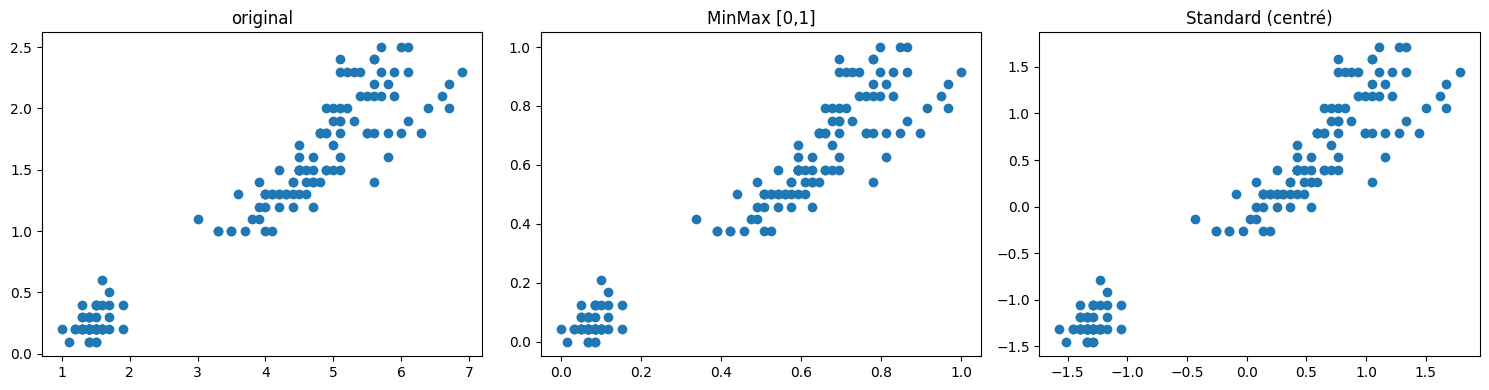

In [70]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data

X_minmax = MinMaxScaler().fit_transform(X)
X_standard = StandardScaler().fit_transform(X)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(X[:, 2], X[:, 3])
ax[0].set_title('original')
ax[1].scatter(X_minmax[:, 2], X_minmax[:, 3])
ax[1].set_title('MinMax [0,1]')
ax[2].scatter(X_standard[:, 2], X_standard[:, 3])
ax[2].set_title('Standard (centré)')
plt.tight_layout()
plt.show()

Même forme, échelles différentes. La mise à l'échelle ne déforme pas les
données elle les remet juste sur une échelle commune. Les positions relatives
des points sont conservées.

### RobustScaler : résister aux aberrations

MinMax et Standard sont sensibles aux valeurs aberrantes. Ajoutons-en pour le
voir.

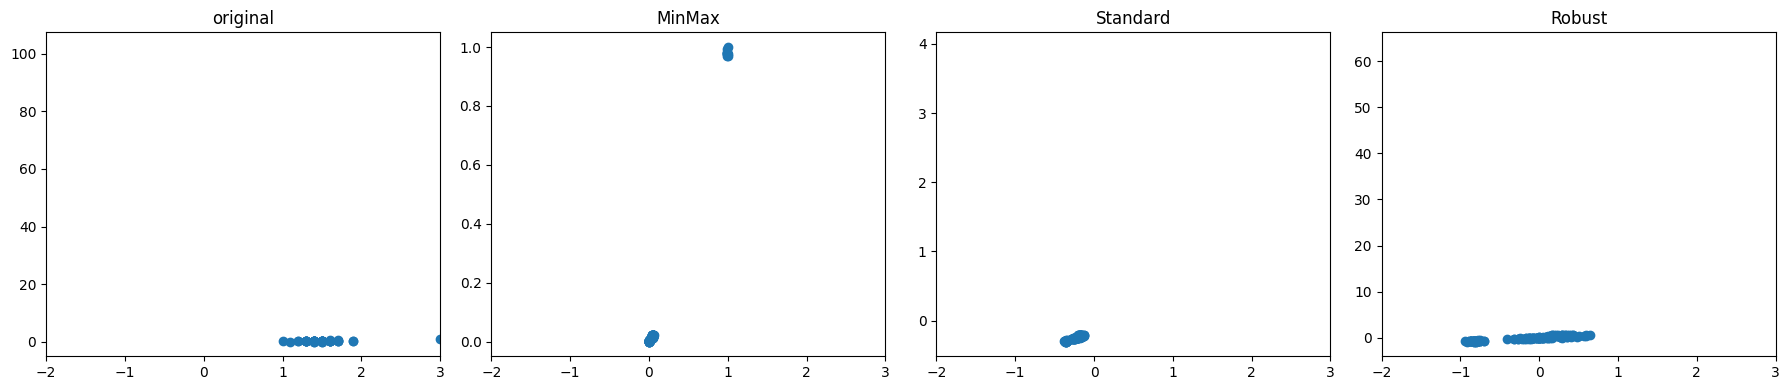

In [71]:
from sklearn.preprocessing import RobustScaler

np.random.seed(0)
iris = load_iris()
X = iris.data

outliers = np.full((10, 4), 100) + np.random.randn(10, 4)
X = np.vstack((X, outliers))

X_minmax = MinMaxScaler().fit_transform(X)
X_standard = StandardScaler().fit_transform(X)
X_robust = RobustScaler().fit_transform(X)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].scatter(X[:, 2], X[:, 3])
ax[0].set_title('original')
ax[1].scatter(X_minmax[:, 2], X_minmax[:, 3])
ax[1].set_title('MinMax')
ax[2].scatter(X_standard[:, 2], X_standard[:, 3])
ax[2].set_title('Standard')
ax[3].scatter(X_robust[:, 2], X_robust[:, 3])
ax[3].set_title('Robust')
for a in ax: a.set_xlim(-2, 3)
plt.tight_layout()
plt.show()

Regarde où chaque méthode place les vraies fleurs (le gros du nuage).

`MinMaxScaler` les écrase dans un coin minuscule : il a calé son échelle sur les
aberrations à 100, donc les 150 vraies valeurs sont comprimées près de 0.

`StandardScaler` fait mieux mais reste perturbé : les aberrations gonflent
l'écart-type.

`RobustScaler` est le seul lisible. Il utilise la médiane et l'écart
interquartile, insensibles aux extrêmes la leçon du notebook 08 appliquée à la
mise à l'échelle.

| Scaler | Centre | Étendue | Robuste ? |
|---|---|---|---|
| MinMax | min | max − min | non, très sensible |
| Standard | moyenne | écart-type | non |
| Robust | médiane | interquartile | oui |

La règle : MinMax ou Standard sur données propres, Robust dès qu'il y a des
aberrations.

## 4. Le feature engineering : PolynomialFeatures

Parfois, les variables brutes ne suffisent pas. Le *feature engineering* consiste
à en créer de nouvelles à partir des existantes, pour donner au modèle de quoi
capter des relations complexes.

In [72]:
from sklearn.preprocessing import PolynomialFeatures

x = np.array([[2]])

print('degré 3 de [2] :', PolynomialFeatures(3).fit_transform(x))

degré 3 de [2] : [[1. 2. 4. 8.]]


`PolynomialFeatures(3)` génère `[1, x, x², x³]` soit `[1, 2, 4, 8]`. Il crée
automatiquement les puissances, ce qu'on faisait à la main au notebook 20.

### L'application : suivre une courbe avec un modèle linéaire

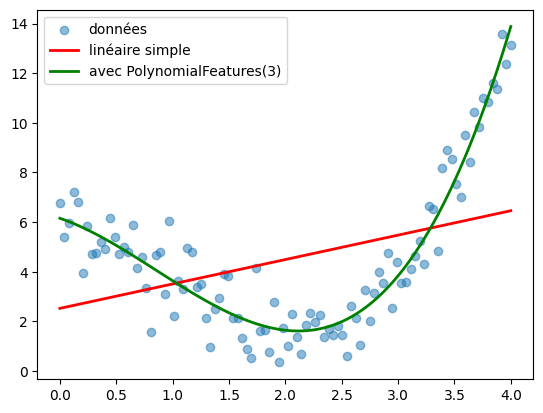

In [73]:
from sklearn.linear_model import LinearRegression

np.random.seed(0)
x = np.linspace(0, 4, 100).reshape(100, 1)
y = x**2 + 5*np.cos(x) + np.random.randn(100, 1)

# Sans PolynomialFeatures
model = LinearRegression().fit(x, y)
y_lin = model.predict(x)

# Avec PolynomialFeatures
x_poly = PolynomialFeatures(3).fit_transform(x)
model_poly = LinearRegression().fit(x_poly, y)
y_poly = model_poly.predict(x_poly)

plt.scatter(x, y, alpha=0.5, label='données')
plt.plot(x, y_lin, c='red', lw=2, label='linéaire simple')
plt.plot(x, y_poly, c='green', lw=2, label='avec PolynomialFeatures(3)')
plt.legend()
plt.show()

La droite rouge rate la courbe. La verte l'épouse pourtant c'est toujours une
`LinearRegression`.

C'est le point conceptuel du notebook 20 : « linéaire » signifie linéaire par
rapport aux coefficients, pas en ligne droite. En ajoutant `x²` et `x³` comme
colonnes, le modèle linéaire peut décrire une courbe.

`PolynomialFeatures` automatise cette création de colonnes. Attention toutefois :
un degré trop élevé mène au surapprentissage du notebook 21 le modèle épouse le
bruit.

## 5. Transformer les distributions

Certaines variables ont une distribution déformée asymétrique, avec une longue
traîne. Beaucoup de modèles préfèrent des variables à peu près symétriques.
`PowerTransformer` corrige ça.

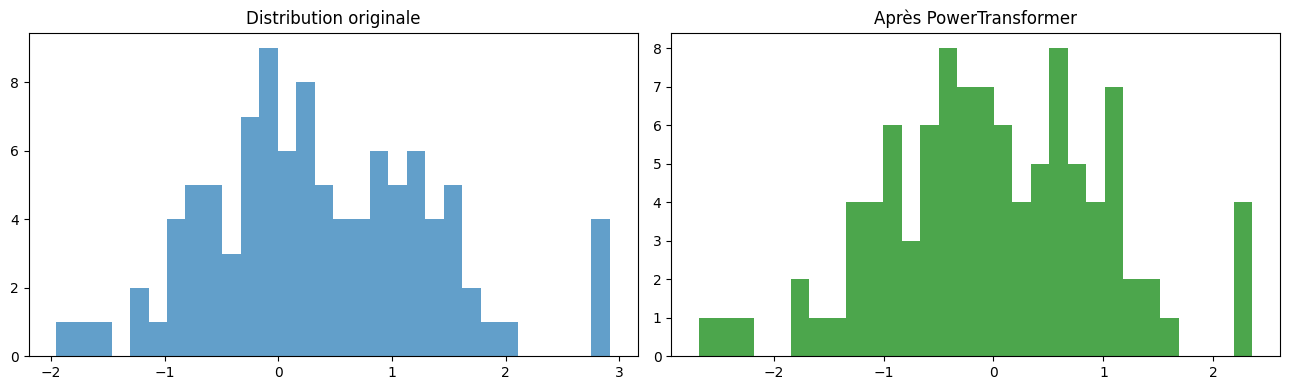

In [74]:
from sklearn.preprocessing import PowerTransformer

np.random.seed(0)
X = np.random.rand(100, 2) + np.random.randn(100, 2)

X2 = PowerTransformer().fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(X[:, 0], bins=30, alpha=0.7)
ax[0].set_title('Distribution originale')
ax[1].hist(X2[:, 0], bins=30, alpha=0.7, color='green')
ax[1].set_title('Après PowerTransformer')
plt.tight_layout()
plt.show()

`PowerTransformer` rend la distribution plus proche d'une cloche normale. Utile
avant les modèles qui supposent des variables normales, et pour atténuer l'effet
des valeurs extrêmes c'est ce qu'on faisait avec le `log` sur le prix du billet
au notebook 19.

### La discrétisation : transformer du continu en catégories

Parfois on veut au contraire regrouper des valeurs continues en tranches.

In [75]:
from sklearn.preprocessing import Binarizer, KBinsDiscretizer

x = np.linspace(0, 5, 10).reshape(-1, 1)

print('Binarizer (seuil 3) : au-dessus 1, en dessous 0')
print(np.hstack((x, Binarizer(threshold=3).fit_transform(x))))

Binarizer (seuil 3) : au-dessus 1, en dessous 0
[[0.         0.        ]
 [0.55555556 0.        ]
 [1.11111111 0.        ]
 [1.66666667 0.        ]
 [2.22222222 0.        ]
 [2.77777778 0.        ]
 [3.33333333 1.        ]
 [3.88888889 1.        ]
 [4.44444444 1.        ]
 [5.         1.        ]]


`Binarizer` transforme en 0 ou 1 selon un seuil. `KBinsDiscretizer` découpe en
plusieurs tranches c'est le `pd.cut` du notebook Pandas, version sklearn.

In [76]:
decoupe = KBinsDiscretizer(n_bins=4, encode='ordinal').fit_transform(x)
print(np.hstack((x, decoupe)))

[[0.         0.        ]
 [0.55555556 0.        ]
 [1.11111111 0.        ]
 [1.66666667 1.        ]
 [2.22222222 1.        ]
 [2.77777778 2.        ]
 [3.33333333 2.        ]
 [3.88888889 3.        ]
 [4.44444444 3.        ]
 [5.         3.        ]]


Les 10 valeurs sont réparties en 4 tranches numérotées de 0 à 3. C'est utile pour
transformer un âge continu en classes d'âge, par exemple.

### FunctionTransformer : ton propre transformer

Pour appliquer n'importe quelle fonction dans un pipeline, `FunctionTransformer`
l'enveloppe.

In [77]:
from sklearn.preprocessing import FunctionTransformer

x = np.linspace(1, 5, 5).reshape(-1, 1)

mon_transformer = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)

print('original :', x.ravel())
print('log1p :', mon_transformer.fit_transform(x).ravel().round(3))

original : [1. 2. 3. 4. 5.]
log1p : [0.693 1.099 1.386 1.609 1.792]


`FunctionTransformer` transforme une fonction ordinaire ici `log1p`, le
`log(1+x)` du notebook 12 en transformer utilisable dans un pipeline.
`inverse_func` permet de revenir en arrière.

C'est la porte d'entrée pour créer ses propres transformations tout en restant
compatible avec l'écosystème sklearn.

## 6. Le Pipeline : tout enchaîner

On a maintenant plusieurs étapes : encoder, mettre à l'échelle, créer des
variables, puis entraîner. Les faire à la main est source d'erreurs surtout la
plus grave, la fuite d'information.

### Le problème sans pipeline

Voici la façon manuelle, correcte mais fragile.

In [78]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Transformer : fit sur le train seulement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Modèle
model = SGDClassifier(random_state=0)
model.fit(X_train_scaled, y_train)

# Test : transform seulement, pas fit
X_test_scaled = scaler.transform(X_test)
print('score :', round(model.score(X_test_scaled, y_test), 3))

score : 0.974


Le point critique est le `fit_transform` sur le train mais seulement
`transform` sur le test. Le scaler apprend la moyenne et l'écart-type du train
uniquement, puis les applique au test.

Si on avait fait `fit_transform` sur tout `X` avant de découper, l'information du
test aurait fui dans le train la faute du notebook 21. Le test doit rester
totalement inconnu.

Faire ça à la main marche, mais on peut se tromper : oublier le `transform`,
réajuster par erreur. Le Pipeline automatise tout et rend l'erreur impossible.

### La solution : make_pipeline

In [79]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), SGDClassifier(random_state=0))
model.fit(X_train, y_train)

print('score :', round(model.score(X_test, y_test), 3))

score : 0.974


Deux lignes au lieu de six, et le même résultat. Le pipeline enchaîne le scaler et
le modèle en un seul objet.

Ce qu'il fait automatiquement :

Sur `fit`, il applique `fit_transform` au scaler puis `fit` au modèle.

Sur `predict` et `score`, il applique `transform` au scaler puis `predict` au
modèle.

Le scaler n'est jamais réajusté sur le test la fuite est structurellement impossible.

### Pourquoi c'est essentiel avec la validation croisée

C'est là que le pipeline devient indispensable. En validation croisée, le scaler
doit être réajusté sur chaque pli d'entraînement, jamais sur le pli de
validation. Sans pipeline, c'est presque impossible à faire correctement à la
main. Avec, c'est automatique.

In [80]:
from sklearn.model_selection import cross_val_score

pipeline = make_pipeline(StandardScaler(), SGDClassifier(random_state=0))
scores = cross_val_score(pipeline, X, y, cv=5)

print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.833 0.967 0.8   0.933 0.933]
moyenne: 0.8933


Ici, à chaque pli, le scaler est ajusté sur les 4 plis d'entraînement et appliqué
au pli de validation. Le pipeline garantit cette discipline sur les 5 découpages,
sans qu'on ait à y penser.

C'est la raison numéro un d'utiliser un pipeline : une validation croisée
honnête même avec des étapes de transformation.

## 7. GridSearch sur un Pipeline

On peut régler les hyperparamètres de toutes les étapes d'un pipeline d'un
coup, avec `GridSearchCV`.

In [81]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

model = make_pipeline(
    PolynomialFeatures(),
    StandardScaler(),
    SGDClassifier(random_state=0))

params = {
    'polynomialfeatures__degree': [2, 3, 4],
    'sgdclassifier__penalty': ['l1', 'l2'],
}

grid = GridSearchCV(model, param_grid=params, cv=4)
grid.fit(X_train, y_train)

print('meilleur score :', round(grid.best_score_, 4))
print('meilleurs params :', grid.best_params_)
print('score sur test :', round(grid.best_estimator_.score(X_test, y_test), 4))

meilleur score : 0.9732
meilleurs params : {'polynomialfeatures__degree': 4, 'sgdclassifier__penalty': 'l1'}
score sur test : 0.9737


### La syntaxe du double underscore

Chaque clé de `params` cible une étape précise du pipeline :

`polynomialfeatures__degree` = le paramètre `degree` de l'étape
`polynomialfeatures`.

Le nom de l'étape en minuscule, deux underscores, puis le nom du paramètre. C'est
ainsi que `GridSearchCV` sait à quelle étape appliquer chaque réglage.

### Les deux pièges de cette cellule

Les valeurs de penalty sont des chaînes : `'l1'` et `'l2'` un « L »
minuscule suivi d'un chiffre, PAS les nombres 11 et 12. La confusion vient de la
police. `'l1'` et `'l2'` sont les deux types de régularisation (lasso et ridge).

Les variables doivent exister. `X_train` en majuscule si c'est ainsi qu'on l'a
nommé. Mélanger `x_train` et `X_train` provoque une `NameError`.

### Tout le pouvoir du pipeline

Cette cellule fait, en un objet, une chaîne complète : créer des variables
polynomiales, les normaliser, entraîner un modèle, et régler les degrés et la
régularisation par validation croisée le tout sans aucune fuite d'information.

C'est l'aboutissement du notebook : le prétraitement et le modèle réunis dans un
estimateur composite, réglé proprement.

## 8. Mémo

### Encoder

| Encodeur | Pour | Note |
|---|---|---|
| `LabelEncoder` | cible `y` | une colonne, plante sur inconnu |
| `OrdinalEncoder` | `X` ordonné | crée un ordre (voulu) |
| `OneHotEncoder` | `X` sans ordre | une colonne par catégorie |

### Mettre à l'échelle

| Scaler | Effet | Robuste ? |
|---|---|---|
| `MinMaxScaler` | entre 0 et 1 | non |
| `StandardScaler` | centré, écart-type 1 | non |
| `RobustScaler` | médiane et quartiles | oui |

### Transformer

| Outil | Effet |
|---|---|
| `PolynomialFeatures` | crée x², x³... |
| `PowerTransformer` | rend la distribution normale |
| `Binarizer` | seuil 0/1 |
| `KBinsDiscretizer` | découpe en tranches |
| `FunctionTransformer` | ta propre fonction |

### Pipeline

```python
model = make_pipeline(StandardScaler(), SGDClassifier())
model.fit(X_train, y_train) # transforme puis entraîne
model.score(X_test, y_test) # transforme puis évalue
```

Réglage : `'nomEtape__parametre'` dans la grille.

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `LabelEncoder` sur `X` 2D | erreur, une colonne seulement |
| Catégorie inconnue | `LabelEncoder` plante |
| Ordinal sur catégories sans ordre | ordre imaginaire, modèle trompé |
| `fit` du scaler sur tout `X` | fuite d'information |
| `fit_transform` sur le test | fuite d'information |
| `penalty=[11, 12]` | erreur, il faut `['l1', 'l2']` |
| MinMax sur données à aberrations | vraies données écrasées |

## 9. Exercices

**Exercice 1**

Sur iris avec 10 valeurs aberrantes ajoutées, entraîne un `KNeighborsClassifier`
dans trois pipelines : sans scaler, avec `StandardScaler`, avec `RobustScaler`.
Compare les scores en validation croisée. Lequel résiste le mieux aux aberrations,
et pourquoi le KNN y est-il si sensible ?

**Exercice 2**

Construis un pipeline `PolynomialFeatures` → `StandardScaler` →
`LinearRegression` sur le jeu diabète. Avec `GridSearchCV`, cherche le meilleur
degré de 1 à 4. Le meilleur degré est-il le plus élevé ? Explique le lien avec le
surapprentissage du notebook 21.

**Exercice 3**

Ce code veut évaluer un modèle avec mise à l'échelle, en validation croisée :

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # sur tout X
scores = cross_val_score(SGDClassifier(), X_scaled, y, cv=5)
```

Il contient une fuite d'information subtile. Explique où elle se cache, pourquoi la
validation croisée devient malhonnête, puis corrige avec un pipeline.

## Pour continuer

Le notebook suivant approfondit un aspect du prétraitement. Ces transformations
resteront présentes dans tous tes projets un modèle passe rarement directement
sur des données brutes.

Le pipeline, en particulier, deviendra ton outil de base : il garantit qu'aucune
information ne fuit du test vers l'entraînement, quelle que soit la complexité de
la chaîne de préparation.

In [82]:
# Exercice 1

In [83]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# iris + 10 aberrations
np.random.seed(0)
iris = load_iris()
X = iris.data.copy()
y = iris.target.copy()

outliers = np.full((10, 4), 100) + np.random.randn(10, 4)
X = np.vstack((X, outliers))
y = np.concatenate((y, np.random.randint(0, 3, 10)))

# Trois pipelines
pipelines = {
    'sans scaler':    make_pipeline(KNeighborsClassifier()),
    'StandardScaler': make_pipeline(StandardScaler(), KNeighborsClassifier()),
    'RobustScaler':   make_pipeline(RobustScaler(), KNeighborsClassifier()),
}

for nom, pipe in pipelines.items():
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'{nom:<16} : {score:.3f}')

sans scaler      : 0.925
StandardScaler   : 0.919
RobustScaler     : 0.887


In [84]:
# Une variable en milliers écrase les autres
np.random.seed(0)
iris = load_iris()
X = iris.data.copy()
X[:, 0] = X[:, 0] * 1000 # première variable × 1000
y = iris.target

for nom, pipe in [('sans scaler', make_pipeline(KNeighborsClassifier())),
                  ('StandardScaler', make_pipeline(StandardScaler(), KNeighborsClassifier()))]:
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'{nom:<16} : {score:.3f}')

sans scaler      : 0.740
StandardScaler   : 0.960


In [85]:
# distance entre deux points, variable 1 en milliers
point_a = np.array([3000, 2])
point_b = np.array([3050, 8])
distance = np.sqrt((3000-3050)**2 + (2-8)**2)
print(f'contribution variable 1 : {(3000-3050)**2}') # 2500
print(f'contribution variable 2 : {(2-8)**2}') # 36

contribution variable 1 : 2500
contribution variable 2 : 36


In [86]:
# Exercice 2

In [87]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score

X, y = load_diabetes(return_X_y=True)

pipeline = make_pipeline(
    PolynomialFeatures(),
    StandardScaler(),
    LinearRegression())

grid = GridSearchCV(
    pipeline,
    param_grid={'polynomialfeatures__degree': [1, 2, 3, 4]},
    cv=5)

grid.fit(X, y)

print('meilleur degré :', grid.best_params_)
print('meilleur score :', round(grid.best_score_, 4))

meilleur degré : {'polynomialfeatures__degree': 1}
meilleur score : 0.4823


In [88]:
for degre in [1, 2, 3, 4]:
    pipe = make_pipeline(PolynomialFeatures(degre), StandardScaler(), LinearRegression())
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'degré {degre} : R² = {score:.4f}')

degré 1 : R² = 0.4823
degré 2 : R² = 0.3915
degré 3 : R² = -158.8748
degré 4 : R² = -38.3741


In [89]:
for degre in [1, 2, 3, 4]:
    n_features = PolynomialFeatures(degre).fit_transform(X).shape[1]
    print(f'degré {degre} : {n_features} variables créées')

degré 1 : 11 variables créées
degré 2 : 66 variables créées
degré 3 : 286 variables créées
degré 4 : 1001 variables créées


In [90]:
# Exercice 3

In [91]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)          # sur tout X
scores = cross_val_score(SGDClassifier(), X_scaled, y, cv=5)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [92]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

pipeline = make_pipeline(StandardScaler(), SGDClassifier(random_state=0))
scores = cross_val_score(pipeline, X, y, cv=5)

print('scores :', scores.round(3))
print('moyenne :', scores.mean().round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


scores : [0. 0. 0. 0. 0.]
moyenne : 0.0


In [93]:
import numpy as np

# Version fautive
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scores_fuite = cross_val_score(SGDClassifier(random_state=0), X_scaled, y, cv=5)

# Version correcte
pipeline = make_pipeline(StandardScaler(), SGDClassifier(random_state=0))
scores_propre = cross_val_score(pipeline, X, y, cv=5)

print(f'avec fuite : {scores_fuite.mean():.4f}')
print(f'sans fuite : {scores_propre.mean():.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


avec fuite : 0.0136
sans fuite : 0.0000
